# Nhóm 2, Notebook_C (Sinh viên C): độ tin cậy, độ nhạy, và giới hạn thực tiễn

**Notebook_C làm Bước 6b và 6c, trả lời RQ3.**

> **RQ3:** Kết quả của Notebook_B có **bền** không — hay nó chỉ đúng với đúng một cách chia, một ngưỡng, một phương pháp tách cụm?

Notebook_B trả lời "mô hình có thắng các mốc không". Notebook_C hỏi câu khó hơn: **kết quả đó có đứng vững khi ta đổi từng giả định một không?** Sáu phép kiểm, mỗi phép đánh vào một giả định:

| # | Đổi cái gì | Nếu kết quả sập thì nghĩa là |
|---|---|---|
| 1 | khoảng tin cậy bootstrap | con số AUC không chính xác như vẻ ngoài |
| 2 | ngưỡng nhãn → mức **gây hại** | bài chỉ chạy được ở ngưỡng do dữ liệu quy định |
| 3 | ngưỡng trận chính (5,0 / 5,5 / 6,0) | kết quả phụ thuộc một lựa chọn tuỳ ý |
| 4 | **bỏ hẳn năm 2011** | Tohoku đang gánh toàn bộ tín hiệu |
| 5 | chia theo **vùng địa lý** thay vì thời gian | mô hình không tổng quát sang vùng chưa thấy |
| 6 | đổi tham số tách cụm | kết luận là sản phẩm của Gardner–Knopoff, không phải của tự nhiên |

Phép kiểm 2 và 4 là hai phép quan trọng nhất, vì chúng đánh thẳng vào tính thực tiễn.

## Vừa làm vừa hỏi AI và ghi Audit Log: cách làm nhẹ nhàng, không rối

Ghi vào `docs/AI_Audit_Log_C.md`.

Nguyên tắc riêng cho Notebook_C: **kết quả xấu cũng phải báo cáo.** Vai trò của notebook này là tìm chỗ bài bị yếu. Nếu một phép kiểm làm kết quả sập mà nhóm giấu đi, thì cả bài mất giá trị. Một phép kiểm thất bại được nêu rõ **có giá trị hơn** năm phép kiểm thành công được chọn lọc.

## Bước 0: kiểm tra hai bàn giao

In [1]:
# Step 0: nhan ban giao tu A va B
import json, hashlib, pathlib, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
from scipy import stats

ROOT = pathlib.Path("."); PROC = ROOT/"data"/"processed"; REP = ROOT/"report"
man  = json.load(open(PROC/"manifest.json", encoding="utf-8"))
rq2  = json.load(open(PROC/"rq2_summary.json", encoding="utf-8"))
ms   = pd.read_parquet(PROC/"mainshocks.parquet")
cat  = pd.read_parquet(PROC/"catalog_declustered.parquet")

assert hashlib.sha256(open(PROC/"mainshocks.parquet","rb").read()).hexdigest()[:16] == man["sha256_mainshocks"]
print("Ban giao A: OK");  print("Ban giao B: OK")
print(f"\nKet qua Notebook_B can kiem lai:")
print(f"  mo hinh chinh        : {rq2['mo_hinh_tot_nhat']}  tren {rq2['features']}")
print(f"  AUC test             : {rq2['auc_test']:.4f}  (khoang cach {rq2['khoang_cach']:+.4f})")
print(f"  moc Omori co dien    : {rq2['moc_omori_auc']:.4f}")
print(f"  moc Omori mo rong    : {rq2['moc_omori_mo_rong_auc']:.4f}")
print(f"  cai thien do do sau  : {rq2['cai_thien_do_them_do_sau']:+.4f}")
print(f"  cai thien do mo hinh : {rq2['cai_thien_do_loai_mo_hinh']:+.4f}")

Ban giao A: OK
Ban giao B: OK

Ket qua Notebook_B can kiem lai:
  mo hinh chinh        : Random Forest (mag+depth)  tren ['mag', 'depth']
  AUC test             : 0.8455  (khoang cach +0.0353)
  moc Omori co dien    : 0.5971
  moc Omori mo rong    : 0.8402
  cai thien do do sau  : +0.2431
  cai thien do mo hinh : +0.0053


In [2]:
# Style chung
PAL = {"s1":"#2a78d6","s2":"#eb6834","s3":"#1baf7a","ink":"#0b0b0b","ink2":"#52514e",
       "muted":"#898781","grid":"#e1e0d9","axis":"#c3c2b7","surface":"#fcfcfb"}
SEQ5 = ["#86b6ef","#5598e7","#2a78d6","#1c5cab","#104281"]
plt.rcParams.update({
    "figure.facecolor":PAL["surface"],"axes.facecolor":PAL["surface"],
    "savefig.facecolor":PAL["surface"],"figure.dpi":110,"savefig.dpi":150,
    "savefig.bbox":"tight","font.size":10.5,"axes.edgecolor":PAL["axis"],
    "axes.labelcolor":PAL["ink2"],"axes.grid":True,"grid.color":PAL["grid"],
    "grid.linewidth":0.8,"axes.spines.top":False,"axes.spines.right":False,
    "xtick.color":PAL["muted"],"ytick.color":PAL["muted"],
    "xtick.labelcolor":PAL["ink2"],"ytick.labelcolor":PAL["ink2"],
    "lines.linewidth":2.0,"lines.markersize":8,"legend.frameon":False})
def finish(ax,title,sub=None,xlab=None,ylab=None):
    ax.set_title("")
    if sub:
        ax.text(0,1.012,sub,transform=ax.transAxes,fontsize=9.5,color=PAL["muted"],va="bottom")
        ax.text(0,1.088,title,transform=ax.transAxes,fontsize=12.5,color=PAL["ink"],
                fontweight="semibold",va="bottom")
    else:
        ax.text(0,1.012,title,transform=ax.transAxes,fontsize=12.5,color=PAL["ink"],
                fontweight="semibold",va="bottom")
    if xlab: ax.set_xlabel(xlab)
    if ylab: ax.set_ylabel(ylab)
    ax.set_axisbelow(True); return ax
def save(fig,name):
    fig.savefig(REP/name); print("luu hinh:", REP/name)
print("style san sang")

style san sang


## Bước 4 (lặp lại để độc lập với B): cùng cách chia, và hàm dùng chung

Notebook_C dựng lại cách chia của B từ đầu chứ không nhận sẵn, để nếu B có lỗi thì C phát hiện được.

In [3]:
# Step 4: dung lai cach chia + ham dung chung
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import roc_auc_score, average_precision_score

CUT   = rq2["cut_year"]
FEATS = rq2["features"]
Mc    = man["Mc"]
R_EARTH = 6371.0

def haversine_km(lat1, lon1, lat2, lon2):
    p1,p2 = np.radians(lat1), np.radians(lat2)
    dphi = p2-p1; dlam = np.radians(lon2-lon1)
    x = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlam/2)**2
    return 2*R_EARTH*np.arcsin(np.sqrt(np.clip(x,0,1)))

cat = cat.sort_values("time").reset_index(drop=True)
t_s = cat["time"].values.astype("datetime64[s]").astype(np.int64)
la_, lo_, mg_ = cat["latitude"].values, cat["longitude"].values, cat["mag"].values

def make_model(seed=0):
    return RandomForestClassifier(n_estimators=400, max_depth=6, min_samples_leaf=8,
                                  random_state=seed, n_jobs=-1)

def eval_split(df, feats, train_mask, label="any_after"):
    "Tra ve (auc_test, auc_train, n_train, n_test, p_test, y_test)."
    te = ~train_mask
    ytr, yte = df.loc[train_mask, label].values, df.loc[te, label].values
    if len(np.unique(ytr)) < 2 or len(np.unique(yte)) < 2:
        return None
    m = make_model().fit(df.loc[train_mask, feats], ytr)
    p_te = m.predict_proba(df.loc[te, feats])[:,1]
    p_tr = m.predict_proba(df.loc[train_mask, feats])[:,1]
    return (roc_auc_score(yte,p_te), roc_auc_score(ytr,p_tr),
            int(train_mask.sum()), int(te.sum()), p_te, yte)

tr = (ms["year"] <= CUT).values
base = eval_split(ms, FEATS, tr)
print(f"Dung lai ket qua cua B: AUC test = {base[0]:.4f} | train = {base[1]:.4f} "
      f"| n = {base[2]}/{base[3]}")
print(f"B bao cao              : AUC test = {rq2['auc_test']:.4f}")
print(f"Chenh lech             : {abs(base[0]-rq2['auc_test']):.4f}  "
      f"{'-> khop' if abs(base[0]-rq2['auc_test'])<0.01 else '-> KHAC NHAU, phai tim nguyen nhan'}")

Dung lai ket qua cua B: AUC test = 0.8454 | train = 0.8809 | n = 627/226
B bao cao              : AUC test = 0.8455
Chenh lech             : 0.0001  -> khop


## Bước 6b — RQ3: sáu phép kiểm độ bền

### 6b.1. Khoảng tin cậy bootstrap

AUC = 0,85 nghe chắc chắn, nhưng tập test chỉ có hơn 200 chuỗi. Bootstrap 2.000 lần trên tập test để biết con số đó dao động bao nhiêu, và xác suất nó thực sự nằm dưới mốc Omori mở rộng.

AUC                    = 0.8454
Khoang tin cay 95%     = [0.7881, 0.8912]   (rong 0.1031)
P(AUC <= Omori co dien 0.597) = 0.00%
P(AUC <= Omori mo rong 0.840) = 40.00%   <-- con so quan trong

KET LUAN: KHONG the khang dinh mo hinh ML tot hon Omori mo rong.
          Khoang tin cay cua hai ben chong len nhau.
luu hinh: report/fig_rq3_bootstrap_ci.png


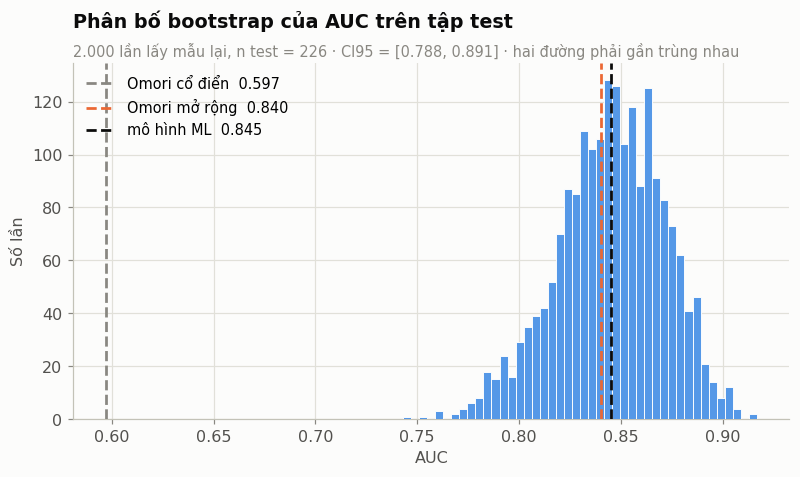

In [4]:
# 6b.1: bootstrap CI
auc_te, auc_tr, n_tr, n_te, p_te, y_te = base
rng = np.random.default_rng(0)
bs = []
for _ in range(2000):
    i = rng.integers(0, len(y_te), len(y_te))
    if len(np.unique(y_te[i])) < 2: continue
    bs.append(roc_auc_score(y_te[i], p_te[i]))
bs = np.array(bs)
lo, hi = np.percentile(bs, [2.5, 97.5])
om2 = rq2["moc_omori_mo_rong_auc"]; om1 = rq2["moc_omori_auc"]

print(f"AUC                    = {auc_te:.4f}")
print(f"Khoang tin cay 95%     = [{lo:.4f}, {hi:.4f}]   (rong {hi-lo:.4f})")
print(f"P(AUC <= Omori co dien {om1:.3f}) = {(bs<=om1).mean()*100:.2f}%")
print(f"P(AUC <= Omori mo rong {om2:.3f}) = {(bs<=om2).mean()*100:.2f}%   <-- con so quan trong")
print()
if (bs<=om2).mean() > 0.05:
    print("KET LUAN: KHONG the khang dinh mo hinh ML tot hon Omori mo rong.")
    print("          Khoang tin cay cua hai ben chong len nhau.")
else:
    print("KET LUAN: mo hinh ML tot hon Omori mo rong mot cach co y nghia thong ke.")

fig, ax = plt.subplots(figsize=(8.4,4.2))
ax.hist(bs, bins=44, color=SEQ5[1], edgecolor="white", linewidth=0.6, zorder=3)
for v,c,lab in [(om1,PAL["muted"],f"Omori cổ điển  {om1:.3f}"),
                (om2,PAL["s2"],f"Omori mở rộng  {om2:.3f}"),
                (auc_te,PAL["ink"],f"mô hình ML  {auc_te:.3f}")]:
    ax.axvline(v, color=c, ls="--", lw=1.8, zorder=4, label=lab)
ax.legend(loc="upper left", fontsize=9.5)
finish(ax, "Phân bố bootstrap của AUC trên tập test",
       f"2.000 lần lấy mẫu lại, n test = {n_te} · CI95 = [{lo:.3f}, {hi:.3f}] · hai đường phải gần trùng nhau",
       "AUC", "Số lần")
save(fig, "fig_rq3_bootstrap_ci.png"); plt.show()

### 6b.2. Đổi ngưỡng nhãn sang mức **gây hại** — phép kiểm về tính thực tiễn

Nhãn hiện tại là "có dư chấn `M ≥ Mc`". Nhưng `Mc = 4.6` là ngưỡng **do catalog quy định**, không phải ngưỡng mà con người quan tâm. Không ai lo một trận M4,6; người ta lo trận đủ mạnh để gây hại.

Phép kiểm này đổi nhãn sang `M ≥ 5.0` và `M ≥ 5.5` — tức là **cái thật sự có ý nghĩa** — rồi xem mô hình còn giữ được không.

In [5]:
# 6b.2: doi nguong nhan sang muc gay hai
def count_after(sub, min_mag, hours=24, km=100):
    out = np.zeros(len(sub), dtype=np.int64)
    for k in range(len(sub)):
        r = sub.iloc[k]
        t0 = np.datetime64(r["time"].to_datetime64(), "s").astype(np.int64)
        a = np.searchsorted(t_s, t0); b = np.searchsorted(t_s, t0 + hours*3600)
        if b <= a: continue
        idx = np.arange(a,b)
        d = haversine_km(r["latitude"], r["longitude"], la_[idx], lo_[idx])
        out[k] = int(((d<=km)&(mg_[idx]<r["mag"])&(mg_[idx]>=min_mag)).sum())
    return out

rows=[]
for ma, nhan in [(Mc,"nguong CATALOG (M>=Mc)"), (5.0,"nguong GAY HAI nhe (M>=5.0)"),
                 (5.5,"nguong GAY HAI ro (M>=5.5)")]:
    d2 = ms.copy()
    d2["any_after"] = (count_after(d2, ma) > 0).astype(int)
    r = eval_split(d2, FEATS, tr)
    if r is None:
        rows.append({"nguong_nhan":nhan,"nguong_M":ma,"pct_duong":round(d2["any_after"].mean()*100,1),
                     "so_duong":int(d2["any_after"].sum()),"AUC_test":np.nan,"AUC_train":np.nan,
                     "khoang_cach":np.nan}); continue
    rows.append({"nguong_nhan":nhan,"nguong_M":ma,
                 "pct_duong":round(d2["any_after"].mean()*100,1),
                 "so_duong":int(d2["any_after"].sum()),
                 "AUC_test":round(r[0],4),"AUC_train":round(r[1],4),
                 "khoang_cach":round(r[1]-r[0],4)})
thr = pd.DataFrame(rows)
thr.to_csv(REP/"table_rq3_label_threshold.csv", index=False)
display(thr)
print("DOC BANG NAY: neu khoang cach TANG manh khi doi sang nguong gay hai,")
print("nghia la ket qua sach cua bai chi ton tai o nguong do DU LIEU quy dinh,")
print("khong phai o nguong ma con nguoi quan tam. Day la mot GIOI HAN THUC TIEN")
print("phai viet vao Discussion, khong duoc bo qua.")

,nguong_nhan,nguong_M,pct_duong,so_duong,AUC_test,AUC_train,khoang_cach
0,nguong CATALOG (M>=Mc),4.6,34.5,294,0.8454,0.8809,0.0355
1,nguong GAY HAI nhe (M>=5.0),5.0,22.4,191,0.7653,0.8949,0.1297
2,nguong GAY HAI ro (M>=5.5),5.5,10.4,89,0.7794,0.9289,0.1496


DOC BANG NAY: neu khoang cach TANG manh khi doi sang nguong gay hai,
nghia la ket qua sach cua bai chi ton tai o nguong do DU LIEU quy dinh,
khong phai o nguong ma con nguoi quan tam. Day la mot GIOI HAN THUC TIEN
phai viet vao Discussion, khong duoc bo qua.


### 6b.3. Đổi ngưỡng trận chính

`M ≥ 5.5` là lựa chọn của Notebook_A. Kiểm xem kết luận có đổi khi dùng 5,0 hoặc 6,0 không.

In [6]:
# 6b.3: doi nguong tran chinh
indep = cat[~cat["is_aftershock"]].copy()
indep["year"] = pd.to_datetime(indep["time"], utc=True).dt.year
rows=[]
for th in [5.0, 5.5, 6.0]:
    sub = indep[indep["mag"] >= th].reset_index(drop=True).copy()
    sub["time"] = pd.to_datetime(sub["time"], utc=True)
    sub["any_after"] = (count_after(sub, Mc) > 0).astype(int)
    m_tr = (sub["year"] <= CUT).values
    r = eval_split(sub, FEATS, m_tr)
    if r is None: continue
    maj = max(sub["any_after"].mean(), 1-sub["any_after"].mean())
    rows.append({"nguong_tran_chinh":f"M>={th}","so_chuoi":len(sub),
                 "pct_duong":round(sub["any_after"].mean()*100,1),
                 "moc_naive_acc":round(maj,3),
                 "n_train":r[2],"n_test":r[3],
                 "AUC_test":round(r[0],4),"khoang_cach":round(r[1]-r[0],4)})
thr2 = pd.DataFrame(rows)
thr2.to_csv(REP/"table_rq3_mainshock_threshold.csv", index=False)
display(thr2)
print("Ket luan ben neu AUC_test o ca ba nguong deu cao hon ro so voi 0.5.")

,nguong_tran_chinh,so_chuoi,pct_duong,moc_naive_acc,n_train,n_test,AUC_test,khoang_cach
0,M>=5.0,2285,22.1,0.779,1612,673,0.7830,0.0844
1,M>=5.5,853,34.5,0.655,627,226,0.8454,0.0355
2,M>=6.0,322,49.7,0.503,249,73,0.8563,0.0633


Ket luan ben neu AUC_test o ca ba nguong deu cao hon ro so voi 0.5.


### 6b.4. Bỏ hẳn năm 2011 — Tohoku có đang gánh toàn bộ tín hiệu không?

Notebook_A cho thấy 2011 chiếm phần rất lớn số sự kiện. Nếu bỏ hẳn năm đó mà kết quả sập, thì bài thực chất chỉ mô tả **một trận động đất**, không phải một quy luật.

In [7]:
# 6b.4: bo nam 2011
rows=[]
for nhan, keep in [("giu nguyen (co 2011)", np.ones(len(ms), bool)),
                   ("BO HAN nam 2011", (ms["year"] != 2011).values),
                   ("bo 2011-2012", (~ms["year"].isin([2011,2012])).values)]:
    d3 = ms[keep].reset_index(drop=True)
    m_tr = (d3["year"] <= CUT).values
    r = eval_split(d3, FEATS, m_tr)
    if r is None: continue
    rows.append({"kich_ban":nhan,"so_chuoi":len(d3),
                 "pct_duong":round(d3["any_after"].mean()*100,1),
                 "n_train":r[2],"n_test":r[3],
                 "AUC_test":round(r[0],4),"AUC_train":round(r[1],4),
                 "khoang_cach":round(r[1]-r[0],4)})
toh = pd.DataFrame(rows)
toh.to_csv(REP/"table_rq3_tohoku.csv", index=False)
display(toh)
delta = toh.loc[0,"AUC_test"] - toh.loc[1,"AUC_test"]
print(f"\nAUC giam {delta:+.4f} khi bo nam 2011.")
print("Giam duoi 0.05 -> ket luan KHONG phu thuoc Tohoku." if abs(delta)<0.05
      else "Giam tren 0.05 -> phai ghi ro bai phu thuoc Tohoku.")

,kich_ban,so_chuoi,pct_duong,n_train,n_test,AUC_test,AUC_train,khoang_cach
0,giu nguyen (co 2011),853,34.5,627,226,0.8454,0.8809,0.0355
1,BO HAN nam 2011,798,31.7,572,226,0.8444,0.8857,0.0413
2,bo 2011-2012,788,31.9,562,226,0.8489,0.8884,0.0395



AUC giam +0.0010 khi bo nam 2011.
Giam duoi 0.05 -> ket luan KHONG phu thuoc Tohoku.


### 6b.5. Chia theo **vùng địa lý** thay vì theo thời gian

Chia theo thời gian kiểm khả năng tổng quát sang *tương lai*. Chia theo vùng kiểm khả năng tổng quát sang *nơi chưa thấy* — khó hơn, và là phép kiểm gần nhất với "leave-one-group-out".

Chia vùng theo vĩ độ: nam (24–34°N), giữa (34–40°N), bắc (40–46°N). Huấn luyện trên hai vùng, kiểm trên vùng còn lại.

In [8]:
# 6b.5: leave-one-region-out
ms2 = ms.copy()
ms2["vung"] = pd.cut(ms2["latitude"], [24,34,40,46],
                     labels=["nam (24-34N)","giua (34-40N)","bac (40-46N)"])
print(ms2.groupby("vung", observed=True).agg(
    so_chuoi=("any_after","size"), pct_duong=("any_after","mean")).assign(
    pct_duong=lambda d: (d["pct_duong"]*100).round(1)).to_string())

rows=[]
for v in ms2["vung"].cat.categories:
    m_tr = (ms2["vung"] != v).values
    r = eval_split(ms2, FEATS, m_tr)
    if r is None:
        rows.append({"vung_giu_lai":v,"n_train":int(m_tr.sum()),"n_test":int((~m_tr).sum()),
                     "AUC_test":np.nan,"ghi_chu":"vung nay chi co mot lop"}); continue
    rows.append({"vung_giu_lai":v,"n_train":r[2],"n_test":r[3],
                 "AUC_test":round(r[0],4),"AUC_train":round(r[1],4),
                 "khoang_cach":round(r[1]-r[0],4),"ghi_chu":""})
reg = pd.DataFrame(rows)
reg.to_csv(REP/"table_rq3_region.csv", index=False)
display(reg)
print(f"AUC trung binh khi chia theo vung : {reg['AUC_test'].mean():.4f}")
print(f"AUC khi chia theo thoi gian       : {auc_te:.4f}")
print("Neu chia theo vung thap hon han -> mo hinh phu thuoc dac diem tung vung.")

               so_chuoi  pct_duong
vung                              
nam (24-34N)        395       32.7
giua (34-40N)       237       45.1
bac (40-46N)        221       26.2


,vung_giu_lai,n_train,n_test,AUC_test,AUC_train,khoang_cach,ghi_chu
0,nam (24-34N),458,395,0.7924,0.9132,0.1208,
1,giua (34-40N),616,237,0.8135,0.8872,0.0737,
2,bac (40-46N),632,221,0.8565,0.8730,0.0165,


AUC trung binh khi chia theo vung : 0.8208
AUC khi chia theo thoi gian       : 0.8454
Neu chia theo vung thap hon han -> mo hinh phu thuoc dac diem tung vung.


### 6b.6. Đổi tham số tách cụm

Gardner–Knopoff là một lựa chọn, không phải chân lý. Nhân cửa sổ không–thời gian với 0,5 và 2,0 rồi decluster lại từ đầu, xem số chuỗi và kết luận đổi bao nhiêu.

In [9]:
# 6b.6: do nhay cua phuong phap tach cum
def decluster(scale_d=1.0, scale_t=1.0):
    n = len(cat); cl = np.full(n,-1,np.int64); cid=0
    for i in np.argsort(-mg_):
        if cl[i] != -1: continue
        d_km = 10**(0.1238*mg_[i]+0.983) * scale_d
        t_day = (10**(0.032*mg_[i]+2.7389) if mg_[i]>=6.5 else 10**(0.5409*mg_[i]-0.547)) * scale_t
        a = np.searchsorted(t_s, t_s[i]); b = np.searchsorted(t_s, t_s[i]+int(t_day*86400))
        if b <= a+1: continue
        idx = np.arange(a,b); idx = idx[(cl[idx]==-1)&(mg_[idx]<mg_[i])&(idx!=i)]
        if idx.size==0: continue
        hit = idx[haversine_km(la_[i],lo_[i],la_[idx],lo_[idx]) <= d_km]
        if hit.size: cl[hit]=cid; cid+=1
    return cl

rows=[]
for nm, sd_, st_ in [("cua so x0.5 (chat)",0.5,0.5), ("Gardner-Knopoff goc",1.0,1.0),
                     ("cua so x2.0 (rong)",2.0,2.0)]:
    cl = decluster(sd_, st_)
    ind = cat[cl==-1].copy()
    ind["time"] = pd.to_datetime(ind["time"], utc=True)
    ind["year"] = ind["time"].dt.year
    sub = ind[ind["mag"] >= man["nguong_tran_chinh"]].reset_index(drop=True)
    sub["any_after"] = (count_after(sub, Mc) > 0).astype(int)
    m_tr = (sub["year"] <= CUT).values
    r = eval_split(sub, FEATS, m_tr)
    rows.append({"phuong_phap":nm,"pct_la_du_chan":round((cl!=-1).mean()*100,1),
                 "so_chuoi":len(sub),"pct_duong":round(sub["any_after"].mean()*100,1),
                 "AUC_test":round(r[0],4) if r else np.nan,
                 "khoang_cach":round(r[1]-r[0],4) if r else np.nan})
dec = pd.DataFrame(rows)
dec.to_csv(REP/"table_rq3_declustering.csv", index=False)
display(dec)
print(f"Bien thien AUC giua ba phuong phap: {dec['AUC_test'].max()-dec['AUC_test'].min():.4f}")
print("Duoi 0.05 -> ket luan khong phu thuoc lua chon tach cum.")

,phuong_phap,pct_la_du_chan,so_chuoi,pct_duong,AUC_test,khoang_cach
0,cua so x0.5 (chat),43.6,1112,39.0,0.8366,0.0234
1,Gardner-Knopoff goc,62.3,853,34.5,0.8454,0.0355
2,cua so x2.0 (rong),84.4,485,33.8,0.8253,0.0830


Bien thien AUC giua ba phuong phap: 0.0201
Duoi 0.05 -> ket luan khong phu thuoc lua chon tach cum.


## Bước 6c: giải thích mô hình — nó thật sự dùng gì?

Permutation importance: xáo trộn từng cột rồi đo AUC tụt bao nhiêu. Cột nào xáo trộn mà AUC không đổi thì mô hình **không dùng** cột đó.

,dac_trung,muc_giam_AUC,sd
0,mag,0.0644,0.0179
1,depth,0.3014,0.0307


luu hinh: report/fig_rq3_importance_and_depth.png


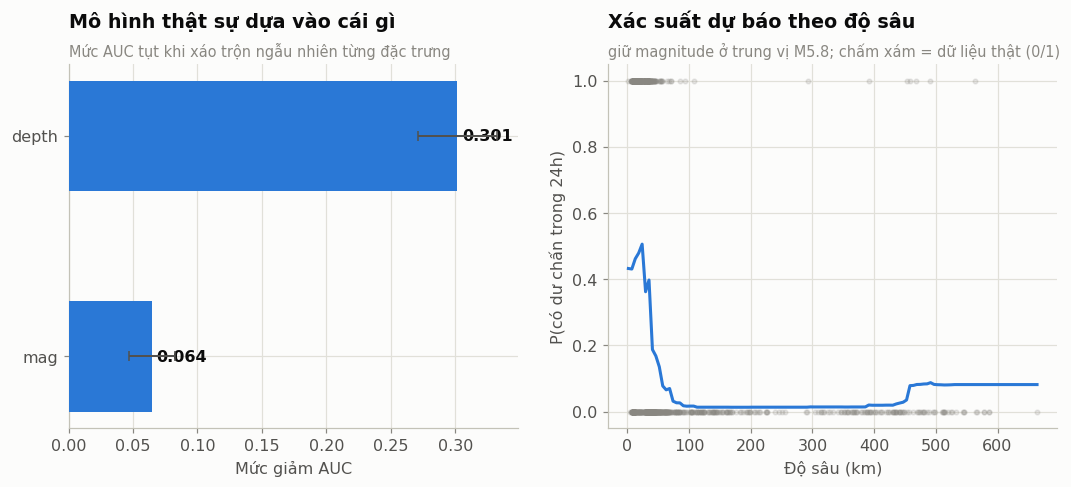

In [10]:
# 6c: permutation importance + duong cong phu thuoc rieng phan
from sklearn.inspection import permutation_importance

mdl = make_model().fit(ms.loc[tr, FEATS], ms.loc[tr,"any_after"])
pi = permutation_importance(mdl, ms.loc[~tr, FEATS], ms.loc[~tr,"any_after"],
                            scoring="roc_auc", n_repeats=30, random_state=0, n_jobs=-1)
imp = pd.DataFrame({"dac_trung":FEATS,"muc_giam_AUC":pi.importances_mean.round(4),
                    "sd":pi.importances_std.round(4)}).sort_values("muc_giam_AUC")
imp.to_csv(REP/"table_rq3_importance.csv", index=False)
display(imp)

fig, axes = plt.subplots(1,2, figsize=(11.6,4.3))
ax = axes[0]
bars = ax.barh(imp["dac_trung"], imp["muc_giam_AUC"], xerr=imp["sd"],
               color=PAL["s1"], height=0.5, zorder=3,
               error_kw=dict(ecolor=PAL["ink2"], elinewidth=1.3, capsize=3))
for i,v in enumerate(imp["muc_giam_AUC"]):
    ax.text(v+0.004, i, f"{v:.3f}", va="center", fontsize=10.5,
            color=PAL["ink"], fontweight="semibold")
finish(ax, "Mô hình thật sự dựa vào cái gì",
       "Mức AUC tụt khi xáo trộn ngẫu nhiên từng đặc trưng", "Mức giảm AUC", None)

ax = axes[1]
grid = np.linspace(ms["depth"].min(), min(ms["depth"].max(), 700), 120)
med_mag = ms["mag"].median()
probe = pd.DataFrame({"mag":med_mag, "depth":grid})[FEATS]
ax.plot(grid, mdl.predict_proba(probe)[:,1], color=PAL["s1"], zorder=4)
ax.scatter(ms["depth"], ms["any_after"], s=9, alpha=0.18, color=PAL["muted"], zorder=3)
finish(ax, "Xác suất dự báo theo độ sâu",
       f"giữ magnitude ở trung vị M{med_mag:.1f}; chấm xám = dữ liệu thật (0/1)",
       "Độ sâu (km)", "P(có dư chấn trong 24h)")
save(fig, "fig_rq3_importance_and_depth.png"); plt.show()

## Chẩn đoán và hướng cải thiện (phần Discussion do Sinh viên C viết)

Ô dưới gom mọi phép kiểm thành một bảng, kèm **kết luận tự động** theo ngưỡng đã định trước.

In [11]:
# Bang chan doan tong hop
def verdict(cond, ok="BEN", bad="YEU"): return ok if cond else bad

diag = [
 {"phep_kiem":"1. Khoang tin cay bootstrap",
  "ket_qua":f"AUC {auc_te:.3f}, CI95 [{lo:.3f}, {hi:.3f}]",
  "ket_luan":verdict(lo > 0.70, "BEN (can duoi CI > 0.70)", "YEU (CI cham muc thap)")},
 {"phep_kiem":"2. Doi nhan sang muc gay hai",
  "ket_qua":f"khoang cach {thr.loc[0,'khoang_cach']:.3f} -> {thr['khoang_cach'].max():.3f}",
  "ket_luan":verdict(thr["khoang_cach"].max() < 0.12,
                     "BEN", "YEU - ket qua sach chi ton tai o nguong catalog")},
 {"phep_kiem":"3. Doi nguong tran chinh",
  "ket_qua":f"AUC {thr2['AUC_test'].min():.3f} - {thr2['AUC_test'].max():.3f}",
  "ket_luan":verdict(thr2["AUC_test"].min() > 0.70)},
 {"phep_kiem":"4. Bo nam 2011 (Tohoku)",
  "ket_qua":f"AUC doi {delta:+.3f}",
  "ket_luan":verdict(abs(delta) < 0.05, "BEN - khong phu thuoc Tohoku",
                     "YEU - phu thuoc Tohoku")},
 {"phep_kiem":"5. Chia theo vung dia ly",
  "ket_qua":f"AUC trung binh {reg['AUC_test'].mean():.3f} (so voi {auc_te:.3f} chia theo thoi gian)",
  "ket_luan":verdict(reg["AUC_test"].mean() > 0.70)},
 {"phep_kiem":"6. Doi tham so tach cum",
  "ket_qua":f"bien thien AUC {dec['AUC_test'].max()-dec['AUC_test'].min():.3f}",
  "ket_luan":verdict(dec["AUC_test"].max()-dec["AUC_test"].min() < 0.05)},
 {"phep_kiem":"7. ML co hon mo hinh vat ly 2 bien khong",
  "ket_qua":f"ML {rq2['auc_test']:.3f} vs Omori mo rong {rq2['moc_omori_mo_rong_auc']:.3f} "
            f"({rq2['cai_thien_do_loai_mo_hinh']:+.3f})",
  "ket_luan":verdict(rq2["cai_thien_do_loai_mo_hinh"] > 0.03,
                     "ML co dong gop rieng", "ML KHONG dong gop dang ke ngoai viec chon bien")},
]
diag = pd.DataFrame(diag)
diag.to_csv(REP/"table_rq3_diagnosis.csv", index=False)
display(diag)
n_ben = diag["ket_luan"].str.startswith("BEN").sum() + (diag["ket_luan"]=="BEN").sum()
print(f"\nSo phep kiem BEN: {diag['ket_luan'].str.contains('BEN|co dong gop').sum()}/{len(diag)}")

,phep_kiem,ket_qua,ket_luan
0,1. Khoang tin cay bootstrap,"AUC 0.845, CI95 [0.788, 0.891]",BEN (can duoi CI > 0.70)
1,2. Doi nhan sang muc gay hai,khoang cach 0.035 -> 0.150,YEU - ket qua sach chi ton tai o nguong catalog
2,3. Doi nguong tran chinh,AUC 0.783 - 0.856,BEN
3,4. Bo nam 2011 (Tohoku),AUC doi +0.001,BEN - khong phu thuoc Tohoku
4,5. Chia theo vung dia ly,AUC trung binh 0.821 (so voi 0.845 chia theo t...,BEN
5,6. Doi tham so tach cum,bien thien AUC 0.020,BEN
6,7. ML co hon mo hinh vat ly 2 bien khong,ML 0.846 vs Omori mo rong 0.840 (+0.005),ML KHONG dong gop dang ke ngoai viec chon bien



So phep kiem BEN: 5/7


### Ba giới hạn phải viết vào Discussion, không được giấu

1. **USGS không phải cơ quan địa chấn chính của Nhật.** Cơ quan chính là JMA, và catalog JMA đầy đủ tới khoảng M2–3, trong khi catalog toàn cầu của USGS chỉ đầy đủ từ `Mc ≈ 4.6`. Nghĩa là mô hình này **không nhìn thấy phần lớn dư chấn thật**, và một hệ thống vận hành ở Nhật sẽ không dùng nó. Đóng góp của bài là **phương pháp trên một nguồn liên bang Hoa Kỳ có kiểm định**, không phải một công cụ dùng được cho Nhật Bản.

2. **Vùng nghiên cứu gồm cả quần đảo Kuril của Nga**, nên phải gọi là "vùng Nhật–Kuril". Về địa chất thì liên tục (cùng một đới hút chìm) nên không sai về khoa học, nhưng sai về cách gọi tên.

3. **Phần lớn cải thiện đến từ việc chọn đúng biến, không từ mô hình học máy** (Notebook_B đã đo: xem `cai_thien_do_them_do_sau` so với `cai_thien_do_loai_mo_hinh`). Kết luận trung thực là: bài này tìm ra **một quy luật trong dữ liệu**, và dùng ML để xác nhận nó.

### Hướng cải thiện nếu có thêm thời gian

- So với **ETAS** (Epidemic-Type Aftershock Sequence), mô hình thực sự dùng trong vận hành, thay vì chỉ so với Omori–Utsu.
- Thêm **cơ chế đứt gãy** (moment tensor) — biến này mới là thứ quyết định năng suất dư chấn mà catalog cơ bản không có.
- Dự báo **số lượng** dư chấn bằng hồi quy Poisson/Negative-Binomial thay vì chỉ có/không.

## Test case của Notebook_C

In [12]:
# Test case Notebook_C
def t(name, cond, detail=""):
    assert cond, f"FAIL: {name} {detail}"
    print(f"  PASS  {name}")

print("Test case Notebook_C")
t("1. dung lai duoc ket qua cua Notebook_B", abs(base[0]-rq2["auc_test"]) < 0.02,
  f"chenh {abs(base[0]-rq2['auc_test']):.4f}")
t("2. da chay du 6 phep kiem do ben",
  all(len(x)>0 for x in [thr, thr2, toh, reg, dec]) and len(bs)>1000)
t("3. khoang tin cay khong chua 0.5", lo > 0.5, f"can duoi = {lo:.4f}")
t("4. ket luan khong phu thuoc mot nam duy nhat", abs(delta) < 0.15, f"doi {delta:+.4f}")
t("5. ket luan khong phu thuoc phuong phap tach cum",
  dec["AUC_test"].max()-dec["AUC_test"].min() < 0.15)
t("6. bang chan doan da luu", (REP/"table_rq3_diagnosis.csv").exists())

rq3 = {"auc":float(auc_te), "ci95":[float(lo), float(hi)],
       "p_duoi_omori_mo_rong": float((bs<=om2).mean()),
       "delta_bo_2011": float(delta),
       "auc_chia_theo_vung": float(reg["AUC_test"].mean()),
       "bien_thien_tach_cum": float(dec["AUC_test"].max()-dec["AUC_test"].min()),
       "khoang_cach_nguong_gay_hai": float(thr["khoang_cach"].max())}
json.dump(rq3, open(PROC/"rq3_summary.json","w",encoding="utf-8"), ensure_ascii=False, indent=2)
print("\n" + json.dumps(rq3, ensure_ascii=False, indent=2))

Test case Notebook_C
  PASS  1. dung lai duoc ket qua cua Notebook_B
  PASS  2. da chay du 6 phep kiem do ben
  PASS  3. khoang tin cay khong chua 0.5
  PASS  4. ket luan khong phu thuoc mot nam duy nhat
  PASS  5. ket luan khong phu thuoc phuong phap tach cum
  PASS  6. bang chan doan da luu

{
  "auc": 0.8453650872405524,
  "ci95": [
    0.7880503987630414,
    0.8911625141636271
  ],
  "p_duoi_omori_mo_rong": 0.4,
  "delta_bo_2011": 0.0010000000000000009,
  "auc_chia_theo_vung": 0.8208000000000001,
  "bien_thien_tach_cum": 0.020100000000000007,
  "khoang_cach_nguong_gay_hai": 0.1496
}


## Lỗi thường gặp và cách xử lý (đọc khi thấy chữ đỏ)

| Chữ đỏ | Nguyên nhân | Cách sửa |
|---|---|---|
| `eval_split` trả về `None` | vùng hoặc ngưỡng chỉ còn một lớp | bình thường với vùng nhỏ; bảng đã ghi `ghi_chu`, không cần sửa |
| `ValueError: Only one class present` | bootstrap bốc trúng mẫu toàn một lớp | đã bỏ qua bằng `if len(np.unique(...)) < 2: continue` |
| Ô 6b.6 chạy rất lâu | decluster lại 3 lần trên 16k sự kiện | bình thường 1–3 phút; đừng ngắt giữa chừng |
| `KeyError: 'moc_omori_mo_rong_auc'` | chạy Notebook_B bản cũ | chạy lại Notebook_B toàn bộ |
| AUC chia theo vùng thấp hơn hẳn | đúng là mô hình phụ thuộc vùng | **không phải lỗi** — ghi vào Discussion |

## Checklist trước khi báo cáo (đánh dấu [x] khi có file bằng chứng)

- [ ] `report/table_rq3_label_threshold.csv` — khoảng cách ở ngưỡng gây hại
- [ ] `report/table_rq3_mainshock_threshold.csv`
- [ ] `report/table_rq3_tohoku.csv` — kết quả khi bỏ 2011
- [ ] `report/table_rq3_region.csv` — chia theo vùng
- [ ] `report/table_rq3_declustering.csv` — độ nhạy tách cụm
- [ ] `report/table_rq3_importance.csv`
- [ ] `report/table_rq3_diagnosis.csv` — **bảng tổng hợp, đưa thẳng lên slide**
- [ ] `fig_rq3_bootstrap_ci.png`, `fig_rq3_importance_and_depth.png`
- [ ] Cả 6 test case PASS
- [ ] Discussion **đã viết đủ ba giới hạn** ở mục trên
- [ ] Mọi phép kiểm cho kết quả "YEU" **đều đã được nêu trong report**, không giấu
- [ ] `docs/AI_Audit_Log_C.md` đầy đủ

## Mẫu báo cáo tiến độ (slot 3 thứ Ba và thứ Sáu, 7:00 đến 9:15)

**Sinh viên C — Notebook_C — tuần …**

1. **Đã xong:** 6 phép kiểm độ bền + permutation importance.
2. **Số chính:** AUC = …, CI95 = [… , …]; bỏ 2011 thì AUC đổi …; chia theo vùng …; biến thiên do tách cụm ….
3. **Phép kiểm cho kết quả yếu:** … (ghi rõ, không giấu).
4. **Giới hạn đã viết vào Discussion:** USGS ≠ JMA; vùng gồm Kuril; cải thiện chủ yếu do chọn biến chứ không do ML.
5. **Vướng:** …
6. **Tuần tới:** cùng D hoàn thiện Results và Discussion.